Example Pipeline for Segmented Search

People-only, box-prompted: YOLOv8n detects person boxes, then SAM's `SamPredictor` decodes exactly one mask per box (instead of `SamAutomaticMaskGenerator`'s full-scene grid).

In [2]:
import os
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

import numpy as np
import torch
import matplotlib.pyplot as plt
import cv2

In [3]:
import sys
sys.path.append("..")
from segment_anything import sam_model_registry, SamPredictor

sam_checkpoint = "sam_vit_h_4b8939.pth"
model_type = "vit_h"

device = "cuda"

torch.cuda.empty_cache()

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)

# SamPredictor runs the image encoder once, then decodes a mask only for
# each prompt it's given. Prompting with the YOLO boxes means we pay for
# len(person_boxes) decodes instead of SamAutomaticMaskGenerator's ~1024
# grid points.
predictor = SamPredictor(sam)

c:\Users\User\Desktop\Code\personal\.venv\Lib\site-packages\torch\nn\modules\module.py:1369: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\c10/cuda/CUDAAllocatorConfig.h:40.)
  return t.to(


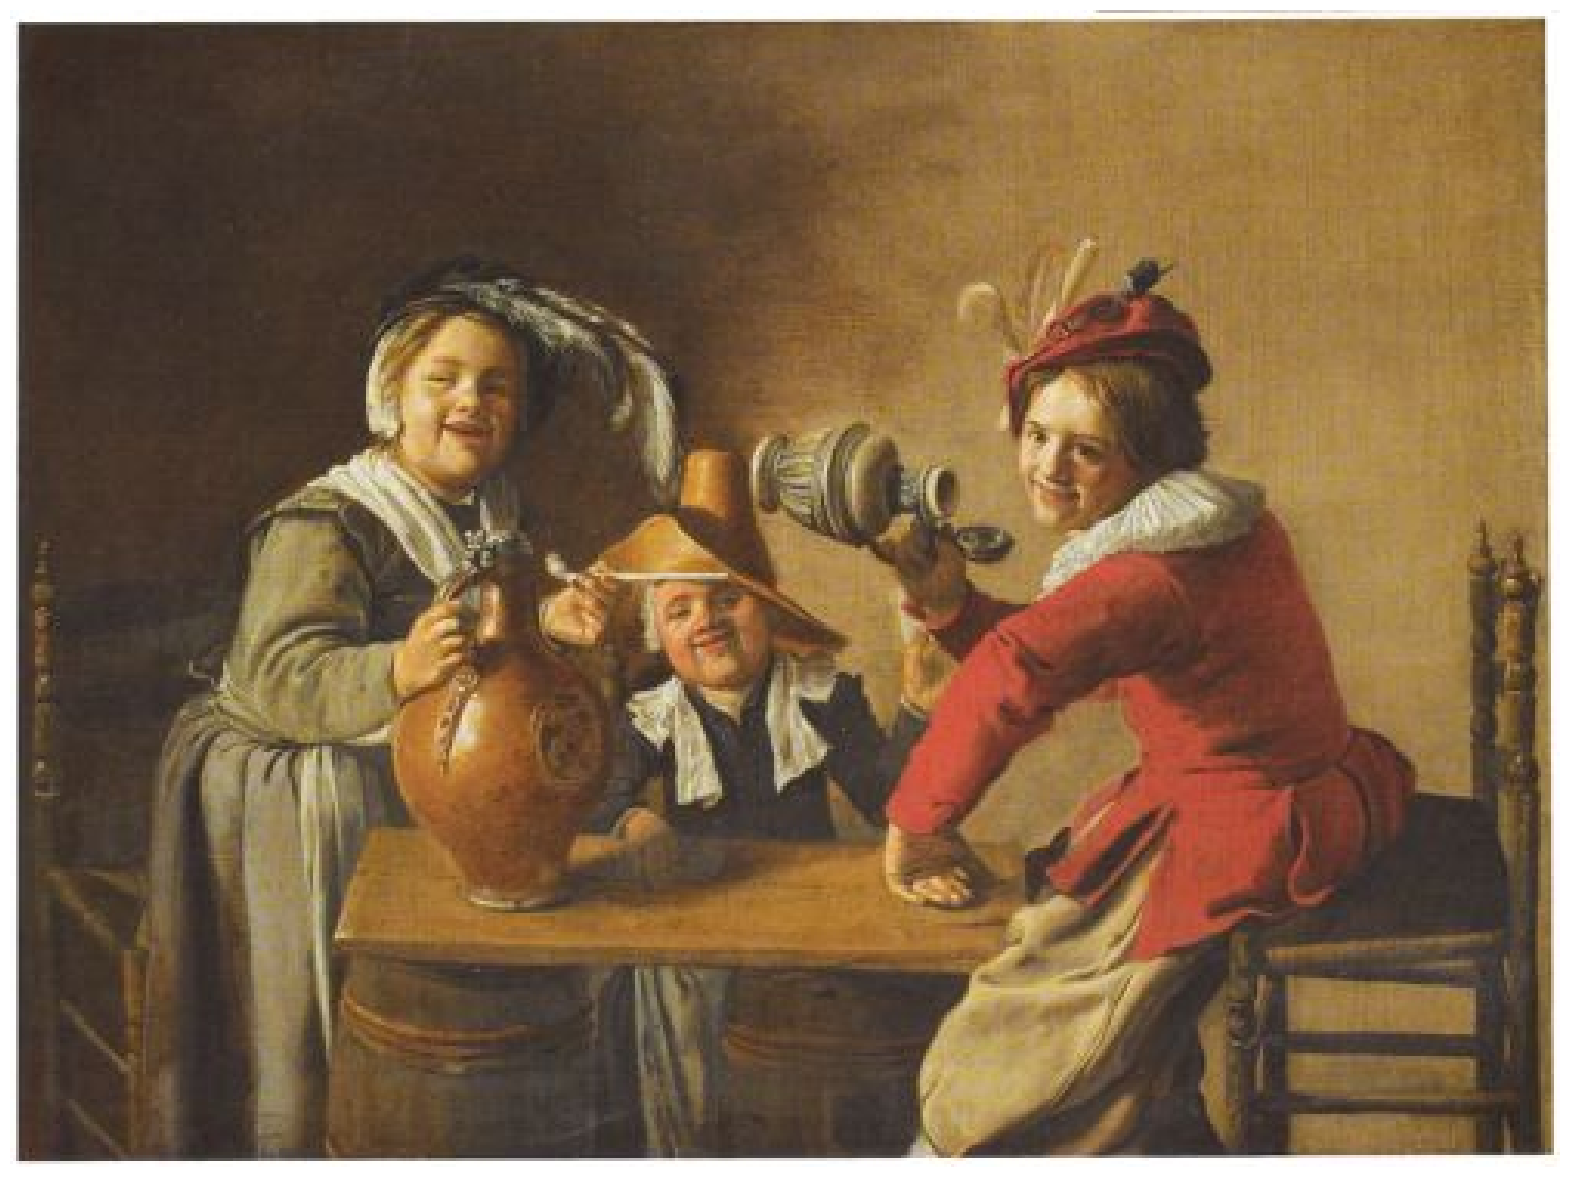

In [85]:
image = cv2.imread("images/RKD Research Merry company of children smoking and drinking, first half 1630s.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

max_dim = 640
scale = max_dim / max(image.shape[:2])
if scale < 1:
    new_size = (int(image.shape[1] * scale), int(image.shape[0] * scale))
    image = cv2.resize(image, new_size, interpolation=cv2.INTER_AREA)

plt.figure(figsize=(20,20))
plt.imshow(image)
plt.axis('off')
plt.show()

In [32]:
def show_anns(anns):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:,:,3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.35]])
        img[m] = color_mask
    ax.imshow(img)

In [86]:
from ultralytics import YOLO

yolo = YOLO("yolov8n.pt")

results = yolo.predict(image, classes = [0], conf = 0.3)
print(f"Detected {len(results[0].boxes)} people")
results[0].show()


0: 480x640 2 persons, 179.6ms
Speed: 29.1ms preprocess, 179.6ms inference, 42.7ms postprocess per image at shape (1, 3, 480, 640)
Detected 2 people


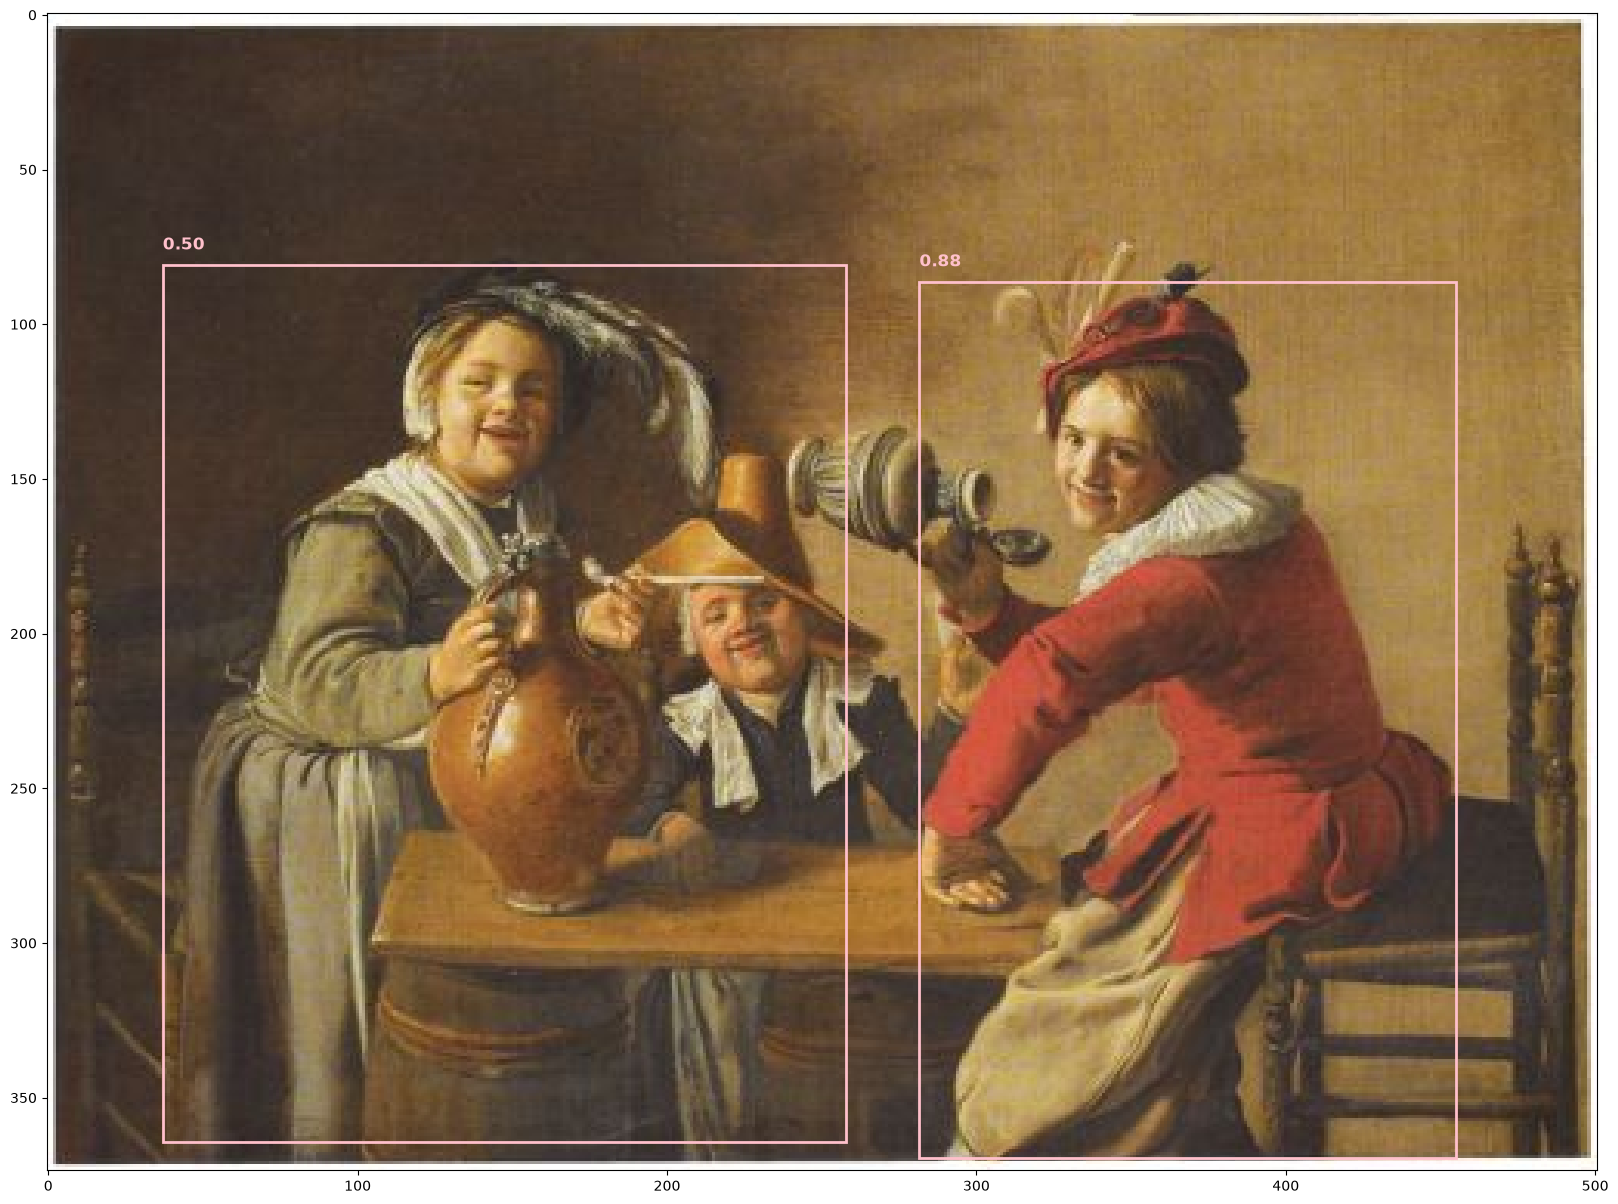

In [87]:
fig, ax = plt.subplots(figsize = (20, 20))
ax.imshow(image)
person_boxes = results[0].boxes.xyxy.cpu().numpy()

for box, conf in zip(person_boxes , results[0].boxes.conf):
    x0, y0, x1, y1 = box
    ax.add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0,
                 fill = False, edgecolor = 'pink', linewidth = 2))
    ax.text(x0, y0 -5, f"{conf:.2f}", color = "pink", fontsize = 12, weight = 'bold')

In [92]:
predictor.set_image(image)
if len(person_boxes) == 0:
    person_masks = np.zeros((0, image.shape[0], image.shape[1]), dtype=bool)
    scores = np.zeros((0,))
else:
    boxes_t = torch.tensor(person_boxes, device=device)
    transformed_boxes = predictor.transform.apply_boxes_torch(boxes_t, image.shape[:2])
    with torch.no_grad():
        person_masks, scores, _ = predictor.predict_torch(
            point_coords=None,
            point_labels=None,
            boxes=transformed_boxes,
            multimask_output=False,  # one mask per box instead of SAM's usual 3 candidates
        )
    person_masks = person_masks.squeeze(1).cpu().numpy()
    scores = scores.squeeze(1).cpu().numpy()

In [95]:
print(f"{len(person_masks)} person mask(s), scores: {np.round(scores, 3)}")

person_anns = [
    {"segmentation": m, "area": int(m.sum())}
    for m in person_masks
]

2 person mask(s), scores: [      0.982       0.984]


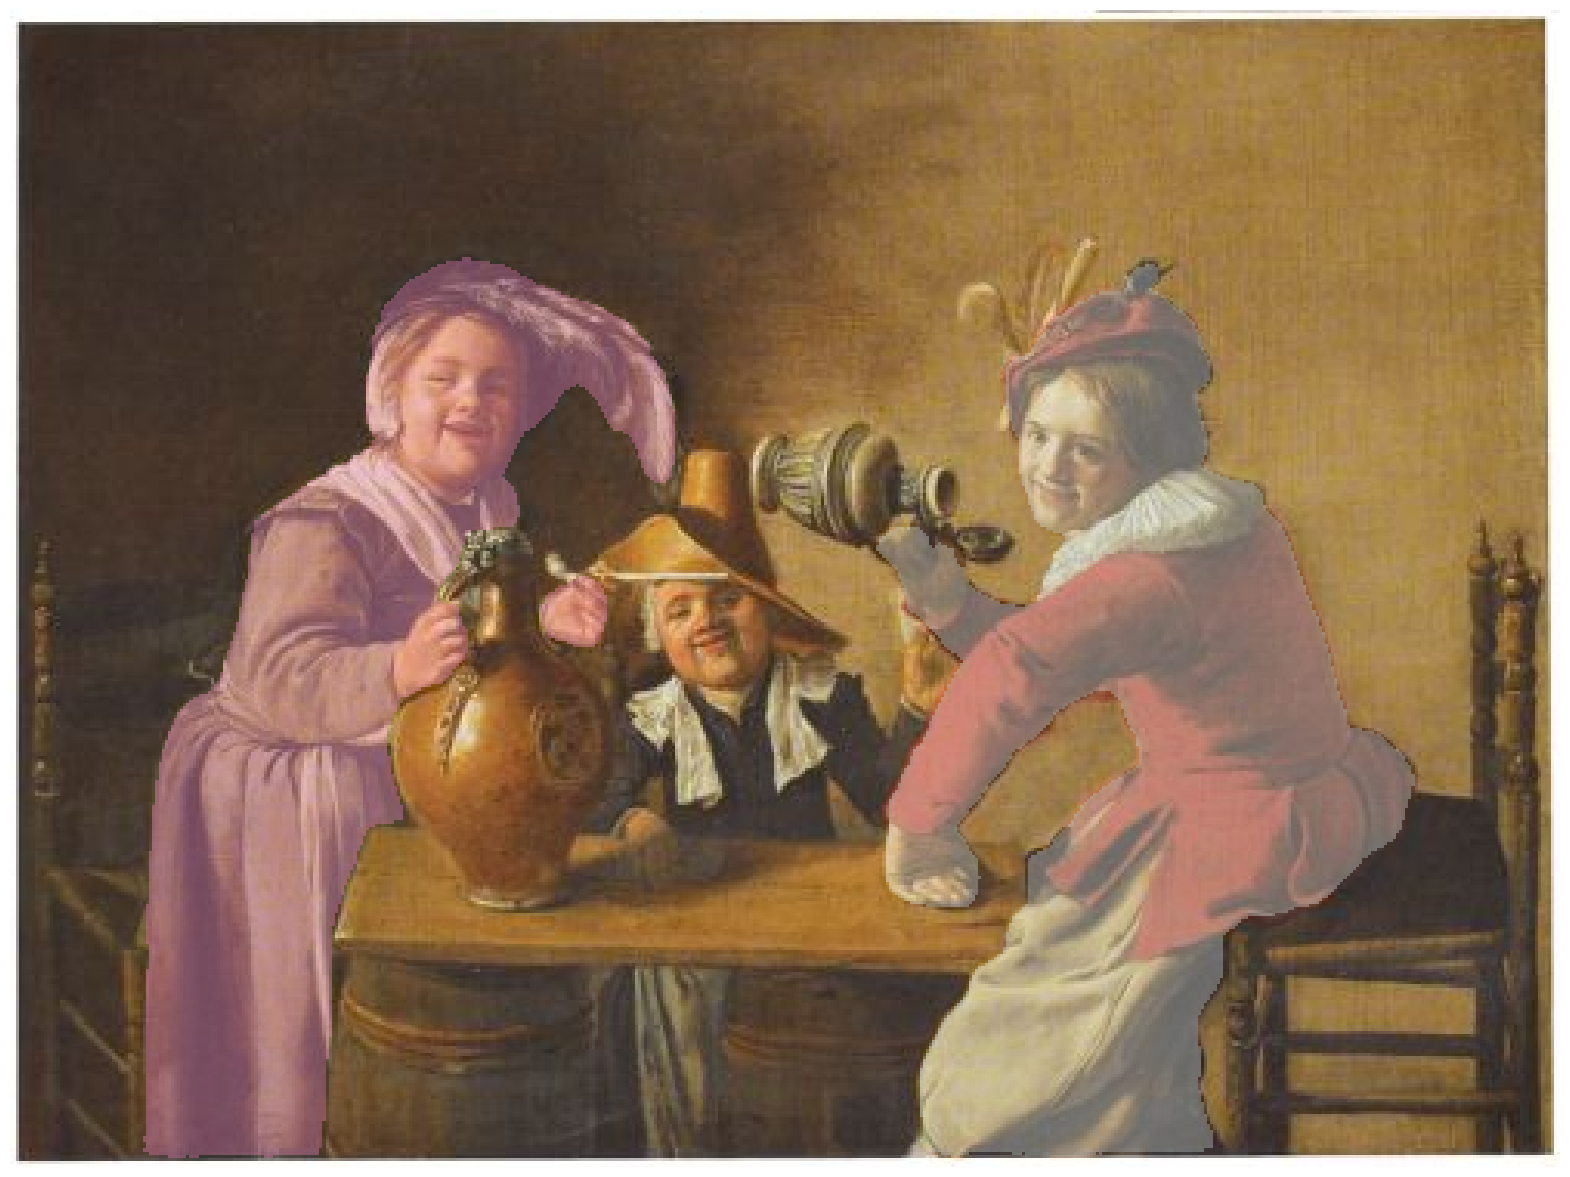

In [96]:
plt.figure(figsize=(20,20))
plt.imshow(image)
show_anns(person_anns)
plt.axis('off')
plt.show()

In [29]:
segments_dir = "segments"
os.makedirs(segments_dir, exist_ok=True)

for i, mask in enumerate(person_masks):
    ys, xs = np.where(mask)
    if len(xs) == 0:
        continue
    x0, x1 = xs.min(), xs.max()
    y0, y1 = ys.min(), ys.max()

    # Crop to the mask's bounding box, then whiteout everything outside
    # the mask itself (jpg has no alpha channel, so this stands in for
    # transparency).
    crop = image[y0:y1 + 1, x0:x1 + 1].copy()
    crop_mask = mask[y0:y1 + 1, x0:x1 + 1]
    crop[~crop_mask] = 255

    out_path = os.path.join(segments_dir, f"segment_{i}.jpg")
    cv2.imwrite(out_path, cv2.cvtColor(crop, cv2.COLOR_RGB2BGR))

print(f"Saved {len(person_masks)} segment(s) to {segments_dir}/")

Saved 6 segment(s) to segments/
